# Proyecto Final: Clasificación de latidos ECG con MIT-BIH

En este proyecto se trabaja con el dataset **ECG Heartbeat Categorization Dataset**, en concreto con la parte **MIT-BIH Arrhythmia**. Cada fila representa un latido cardiaco ya preprocesado y reescalado a una longitud fija de 187 puntos temporales. La última columna contiene la clase del latido.

El objetivo es construir un clasificador capaz de distinguir entre 5 tipos de latidos:

| Clase | Etiqueta | Descripción |
|---|---|---|
| 0 | N | Latido normal |
| 1 | S | Latido supraventricular prematuro |
| 2 | V | Contracción ventricular prematura |
| 3 | F | Fusión de latido ventricular y normal |
| 4 | Q | Latido no clasificable |

La práctica sigue una estructura parecida a los notebooks de clase: primero se cargan y analizan los datos, después se prueban varios modelos y finalmente se comparan los resultados. Como baseline trivial se usa la clase mayoritaria, como baseline clásico se usa un clasificador lineal, y como modelo principal se entrena una CNN 1D con PyTorch.

## Relación con el enunciado y el temario

Se escoge la **Opción 1: clasificación** propuesta en el enunciado, usando el dataset MIT-BIH del conjunto ECG Heartbeat Categorization. Por tanto, la tarea no es forecasting ni detección no supervisada de anomalías, sino **clasificación supervisada de series temporales univariadas**.

La práctica queda conectada con el temario de la asignatura de esta forma:

- **Introducción a series temporales**: cada latido se interpreta como una secuencia ordenada de 187 valores.
- **Preprocesado y análisis**: se revisan dimensiones, clases, desbalanceo, ejemplos individuales, patrones medios y estadísticas por clase.
- **Aprendizaje supervisado**: se comparan un baseline trivial, un RedgeClassifier, un MLP, un RandomForest, una LSTM y una red neuronal convolucional 1D.
- **Deep Learning para series temporales**: se usa una CNN 1D porque puede aprender patrones locales en la morfología del ECG, de forma parecida a la idea de usar convoluciones en arquitecturas como InceptionTime, pero manteniendo el modelo más sencillo.
- **Evaluación**: se usan accuracy, F1 macro, F1 weighted, `classification_report` y matriz de confusión para no depender solo de una métrica.

También se separa una parte de validación a partir del entrenamiento para elegir hiperparámetros. El conjunto de test original se reserva para la comparación final.

## Instalación e importación de librerías

La celda siguiente instala `kagglehub` solo si no está disponible. Esta librería permite descargar el dataset público desde Kaggle de forma bastante cómoda.

In [1]:
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("kagglehub") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])

In [2]:
from pathlib import Path
import shutil
import random
import time
from collections import Counter

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

C:\Users\ftpx\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Fijamos semillas para que los resultados sean reproducibles
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)

Dispositivo: cuda


## Carga del conjunto de datos

Se descarga el dataset de Kaggle si no está ya en la carpeta local. Para no depender de rutas absolutas, se copian los archivos `mitbih_train.csv` y `mitbih_test.csv` a `data/heartbeat/`.

In [4]:
DATA_DIR = Path("data/heartbeat")
DATA_DIR.mkdir(parents=True, exist_ok=True)

train_csv = DATA_DIR / "mitbih_train.csv"
test_csv = DATA_DIR / "mitbih_test.csv"

if not train_csv.exists() or not test_csv.exists():
    dataset_path = Path(kagglehub.dataset_download("shayanfazeli/heartbeat"))
    shutil.copy2(dataset_path / "mitbih_train.csv", train_csv)
    shutil.copy2(dataset_path / "mitbih_test.csv", test_csv)
    print("Dataset descargado y copiado en", DATA_DIR)
else:
    print("Dataset encontrado en", DATA_DIR)

print(train_csv)
print(test_csv)

Dataset encontrado en data\heartbeat
data\heartbeat\mitbih_train.csv
data\heartbeat\mitbih_test.csv


In [5]:
df_train = pd.read_csv(train_csv, header=None)
df_test = pd.read_csv(test_csv, header=None)

print("Shape train:", df_train.shape)
print("Shape test :", df_test.shape)
df_train.head()

Shape train: (87554, 188)
Shape test : (21892, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Cada muestra tiene 188 columnas: 187 puntos de la señal y una etiqueta final. El dataset ya viene separado en entrenamiento y test, así que se mantiene esa división para evaluar de forma limpia.

In [6]:
N_TIMESTEPS = 187
LABEL_COL = 187

class_names = {
    0: "N - Normal",
    1: "S - Supraventricular",
    2: "V - Ventricular",
    3: "F - Fusion",
    4: "Q - No clasificable"
}

print("Columnas de señal:", df_train.columns[:N_TIMESTEPS].min(), "a", df_train.columns[:N_TIMESTEPS].max())
print("Columna label:", LABEL_COL)
print("Clases train:", sorted(df_train[LABEL_COL].unique()))
print("Clases test :", sorted(df_test[LABEL_COL].unique()))

Columnas de señal: 0 a 186
Columna label: 187
Clases train: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Clases test : [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


## EDA y preprocesado

Primero revisamos la distribución de clases. Este punto es importante porque en problemas médicos suele haber desbalanceo: hay muchos más ejemplos normales que ejemplos patológicos o raros.

In [7]:
def class_distribution(df, name):
    counts = df[LABEL_COL].astype(int).value_counts().sort_index()
    dist = pd.DataFrame({
        "clase": counts.index,
        "nombre": [class_names[i] for i in counts.index],
        "n_muestras": counts.values,
        "porcentaje": (counts.values / counts.values.sum() * 100).round(2)
    })
    print(name)
    display(dist)
    return dist

train_dist = class_distribution(df_train, "Distribución train")
test_dist = class_distribution(df_test, "Distribución test")

Distribución train


,clase,nombre,n_muestras,porcentaje
0,0,N - Normal,72471,82.77
1,1,S - Supraventricular,2223,2.54
2,2,V - Ventricular,5788,6.61
3,3,F - Fusion,641,0.73
4,4,Q - No clasificable,6431,7.35


Distribución test


,clase,nombre,n_muestras,porcentaje
0,0,N - Normal,18118,82.76
1,1,S - Supraventricular,556,2.54
2,2,V - Ventricular,1448,6.61
3,3,F - Fusion,162,0.74
4,4,Q - No clasificable,1608,7.35


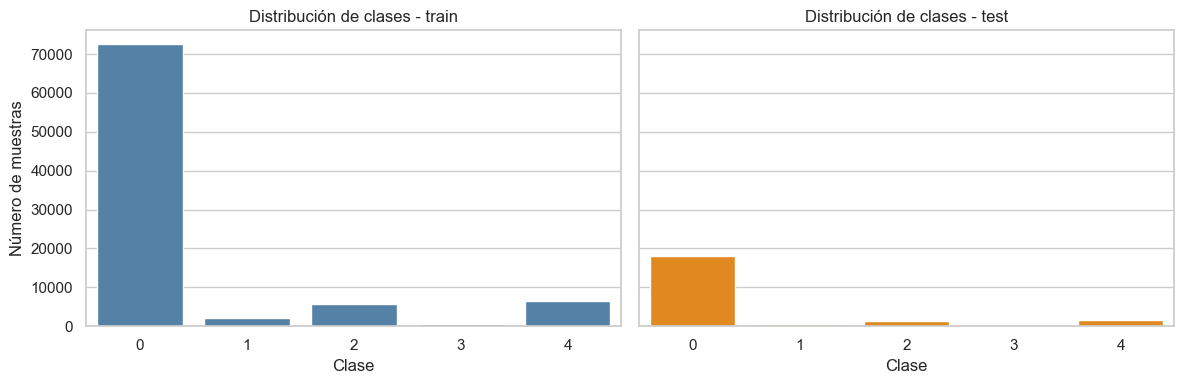

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.barplot(data=train_dist, x="clase", y="n_muestras", ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de clases - train")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Número de muestras")

sns.barplot(data=test_dist, x="clase", y="n_muestras", ax=axes[1], color="darkorange")
axes[1].set_title("Distribución de clases - test")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Se observa un desbalanceo bastante claro. La clase 0 domina el dataset, por lo que además de la accuracy se usará **F1 macro**, que trata todas las clases con el mismo peso.

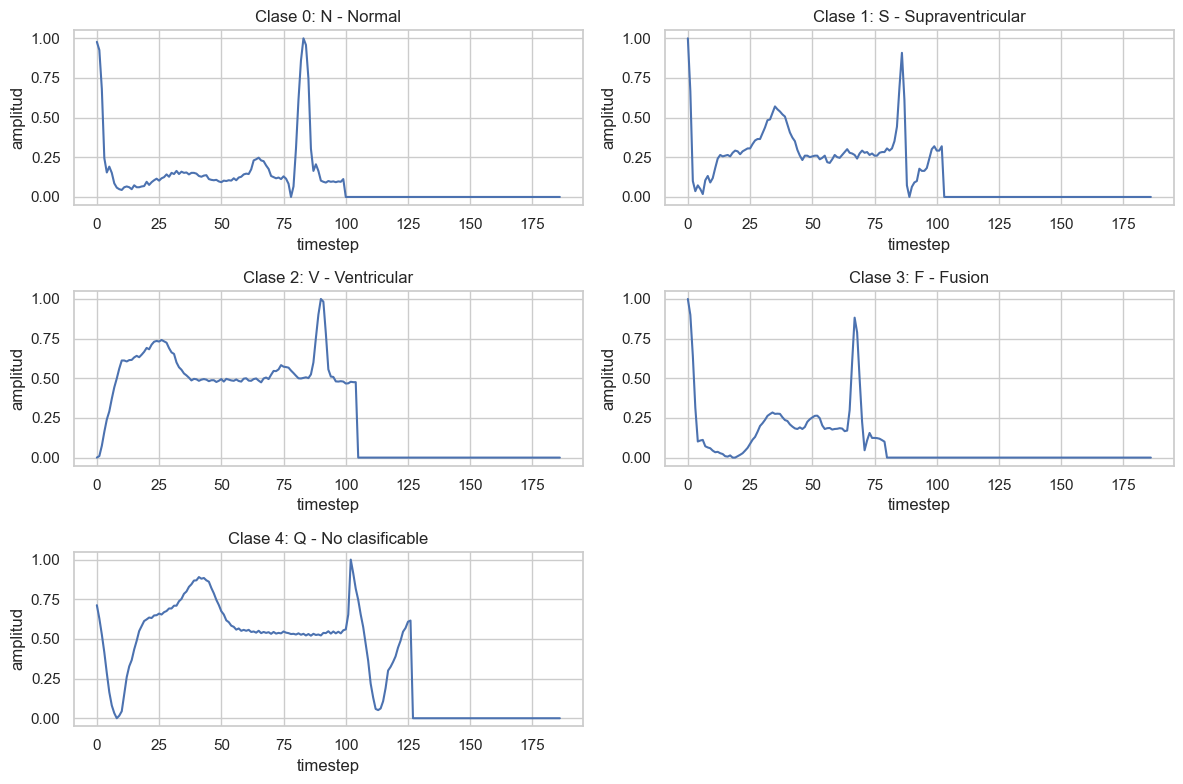

In [9]:
# Visualizamos un ejemplo de cada clase
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.ravel()

for i, clase in enumerate(class_names):
    sample = df_train[df_train[LABEL_COL] == clase].iloc[0, :N_TIMESTEPS].values
    axes[i].plot(sample, linewidth=1.5)
    axes[i].set_title(f"Clase {clase}: {class_names[clase]}")
    axes[i].set_xlabel("timestep")
    axes[i].set_ylabel("amplitud")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

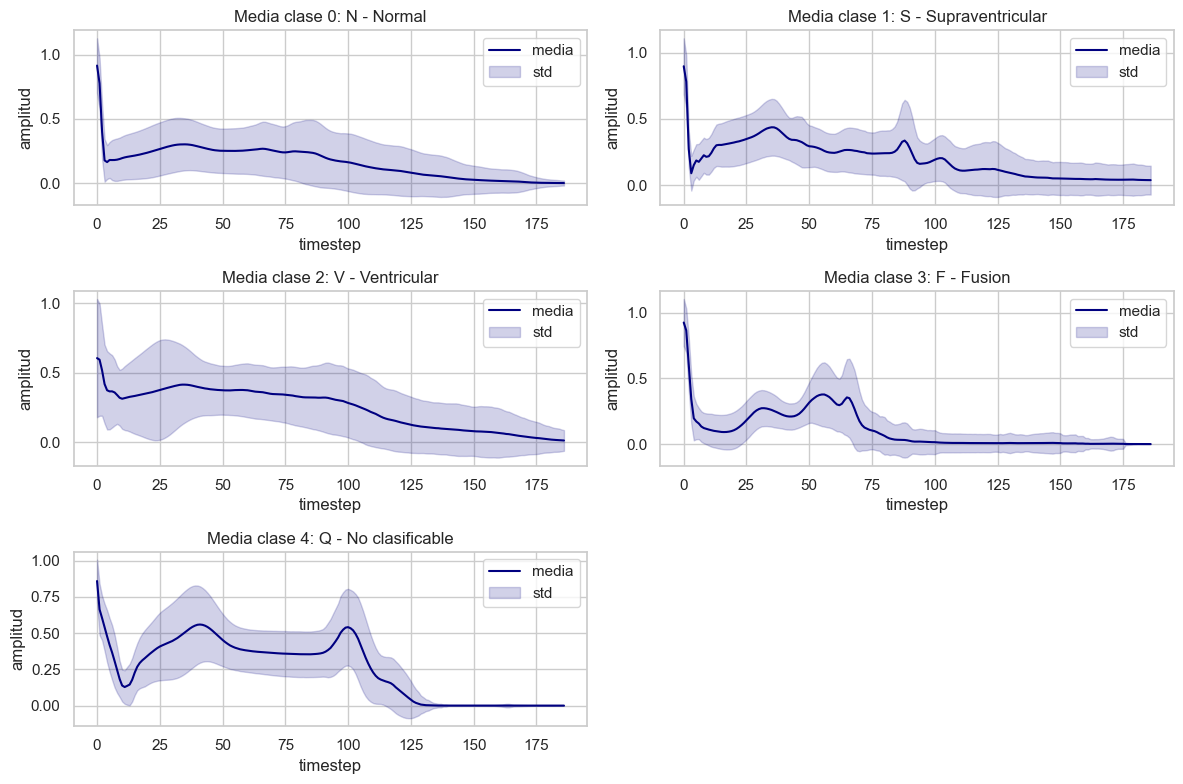

In [10]:
# Patrón medio por clase
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.ravel()

for i, clase in enumerate(class_names):
    subset = df_train[df_train[LABEL_COL] == clase].iloc[:, :N_TIMESTEPS].values
    mean_signal = subset.mean(axis=0)
    std_signal = subset.std(axis=0)
    x = np.arange(N_TIMESTEPS)

    axes[i].plot(x, mean_signal, color="navy", label="media")
    axes[i].fill_between(x, mean_signal - std_signal, mean_signal + std_signal, color="navy", alpha=0.18, label="std")
    axes[i].set_title(f"Media clase {clase}: {class_names[clase]}")
    axes[i].set_xlabel("timestep")
    axes[i].set_ylabel("amplitud")
    axes[i].legend(loc="upper right")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [11]:
# Estadísticas sencillas por clase
stats_rows = []
for clase in class_names:
    subset = df_train[df_train[LABEL_COL] == clase].iloc[:, :N_TIMESTEPS].values
    stats_rows.append({
        "clase": clase,
        "nombre": class_names[clase],
        "media_global": subset.mean(),
        "std_global": subset.std(),
        "min": subset.min(),
        "max": subset.max()
    })

stats_df = pd.DataFrame(stats_rows)
display(stats_df.round(4))

,clase,nombre,media_global,std_global,min,max
0,0,N - Normal,0.1619,0.2176,0.0,1.0
1,1,S - Supraventricular,0.1948,0.2146,0.0,1.0
2,2,V - Ventricular,0.2438,0.2623,0.0,1.0
3,3,F - Fusion,0.1073,0.1930,0.0,1.0
4,4,Q - No clasificable,0.2509,0.2643,0.0,1.0


### Preparación de matrices

El dataset ya está normalizado en rango aproximado `[0, 1]`, así que no se aplica un escalado adicional. Para la CNN se cambia la forma de los datos a `(muestras, canales, timesteps)`, que es el formato habitual para `Conv1d` en PyTorch.

La división original `train/test` del dataset se respeta. Además, dentro de `train` se reserva un 15% como validación estratificada. Esta validación se usa para elegir hiperparámetros de la CNN, y el test se deja para la evaluación final.

In [12]:
X_train_full = df_train.iloc[:, :N_TIMESTEPS].values.astype(np.float32)
y_train_full = df_train[LABEL_COL].values.astype(np.int64)

X_test = df_test.iloc[:, :N_TIMESTEPS].values.astype(np.float32)
y_test = df_test[LABEL_COL].values.astype(np.int64)

print("Rango train:", X_train_full.min(), X_train_full.max())
print("X_train_full:", X_train_full.shape)
print("X_test      :", X_test.shape)

Rango train: 0.0 1.0
X_train_full: (87554, 187)
X_test      : (21892, 187)


In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_full
)

print("Train:", X_train.shape, Counter(y_train))
print("Val  :", X_val.shape, Counter(y_val))
print("Test :", X_test.shape, Counter(y_test))

Train: (74420, 187) Counter({np.int64(0): 61600, np.int64(4): 5466, np.int64(2): 4920, np.int64(1): 1889, np.int64(3): 545})
Val  : (13134, 187) Counter({np.int64(0): 10871, np.int64(4): 965, np.int64(2): 868, np.int64(1): 334, np.int64(3): 96})
Test : (21892, 187) Counter({np.int64(0): 18118, np.int64(4): 1608, np.int64(2): 1448, np.int64(1): 556, np.int64(3): 162})


## Funciones de evaluación

Creo una función común para evaluar todos los modelos. En esta práctica se miran dos métricas principales:

- **Accuracy**: proporción de aciertos totales.
- **F1 macro**: media del F1 de cada clase, útil cuando las clases están desbalanceadas.

In [14]:
results = []

def evaluate_predictions(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")

    results.append({
        "Modelo": model_name,
        "Accuracy": acc,
        "F1 macro": f1_macro,
        "F1 weighted": f1_weighted
    })

    print(f"{model_name}")
    print(f"Accuracy   : {acc:.4f}")
    print(f"F1 macro   : {f1_macro:.4f}")
    print(f"F1 weighted: {f1_weighted:.4f}")
    print()
    print(classification_report(
        y_true,
        y_pred,
        target_names=[class_names[i] for i in sorted(class_names)],
        zero_division=0
    ))

    return acc, f1_macro, f1_weighted


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[class_names[i] for i in sorted(class_names)],
        yticklabels=[class_names[i] for i in sorted(class_names)]
    )
    plt.title(title)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Baseline 1: clase mayoritaria

Este baseline es deliberadamente simple: predice siempre la clase más frecuente del entrenamiento. Sirve para comprobar si los modelos realmente aprenden algo o solo aprovechan el desbalanceo.

Clase mayoritaria: 0 N - Normal
Baseline clase mayoritaria
Accuracy   : 0.8276
F1 macro   : 0.1811
F1 weighted: 0.7495

                      precision    recall  f1-score   support

          N - Normal       0.83      1.00      0.91     18118
S - Supraventricular       0.00      0.00      0.00       556
     V - Ventricular       0.00      0.00      0.00      1448
          F - Fusion       0.00      0.00      0.00       162
 Q - No clasificable       0.00      0.00      0.00      1608

            accuracy                           0.83     21892
           macro avg       0.17      0.20      0.18     21892
        weighted avg       0.68      0.83      0.75     21892



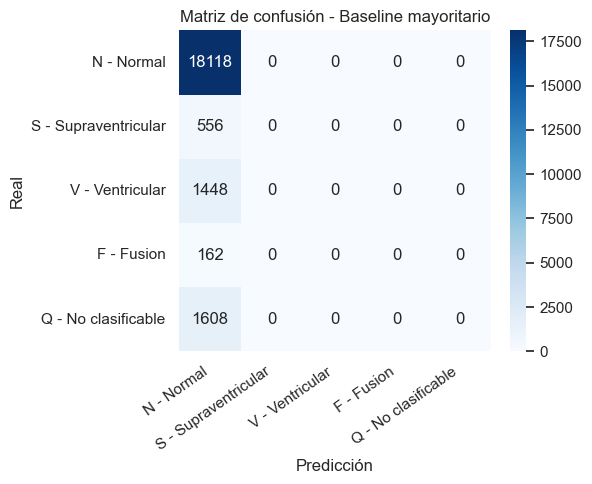

In [15]:
majority_class = Counter(y_train_full).most_common(1)[0][0]
y_pred_majority = np.full_like(y_test, fill_value=majority_class)

print("Clase mayoritaria:", majority_class, class_names[majority_class])
evaluate_predictions("Baseline clase mayoritaria", y_test, y_pred_majority)
plot_confusion(y_test, y_pred_majority, "Matriz de confusión - Baseline mayoritario")

## Baseline 2: clasificador lineal

Como segundo baseline se entrena un `RidgeClassifier`. No es un modelo profundo, pero funciona bien como referencia rápida sobre los 187 puntos temporales originales. Se usa `class_weight='balanced'` para compensar parcialmente el desbalanceo.

Tiempo de entrenamiento: 0.2 segundos
RidgeClassifier balanceado
Accuracy   : 0.6204
F1 macro   : 0.4488
F1 weighted: 0.6970

                      precision    recall  f1-score   support

          N - Normal       0.97      0.59      0.73     18118
S - Supraventricular       0.10      0.63      0.18       556
     V - Ventricular       0.33      0.69      0.44      1448
          F - Fusion       0.06      0.87      0.11       162
 Q - No clasificable       0.69      0.91      0.78      1608

            accuracy                           0.62     21892
           macro avg       0.43      0.74      0.45     21892
        weighted avg       0.88      0.62      0.70     21892



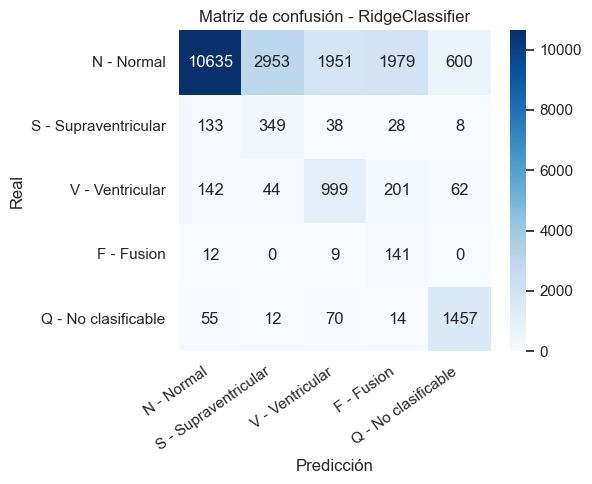

In [16]:
linear_clf = RidgeClassifier(class_weight="balanced")

start = time.time()
linear_clf.fit(X_train, y_train)
print(f"Tiempo de entrenamiento: {time.time() - start:.1f} segundos")

y_pred_linear = linear_clf.predict(X_test)
evaluate_predictions("RidgeClassifier balanceado", y_test, y_pred_linear)
plot_confusion(y_test, y_pred_linear, "Matriz de confusión - RidgeClassifier")

## Experimento 3: features manuales + Random Forest

Además de usar los 187 puntos directamente, se extraen algunas características sencillas de cada latido: media, desviación típica, máximo, energía, posición del pico principal y estadísticas de la primera diferencia. Este experimento imita una aproximación más clásica de aprendizaje automático: resumir la serie temporal en variables y entrenar un clasificador sobre esas variables.

No debería superar necesariamente a la CNN, porque se pierde parte de la forma temporal fina de la señal, pero sirve como comparación adicional y ayuda a entender si el problema se puede resolver con descriptores simples.

In [17]:
def extract_basic_features(X):
    diff = np.diff(X, axis=1)
    area = np.trapezoid(X, axis=1)
    peak_idx = np.argmax(X, axis=1) / X.shape[1]

    features = pd.DataFrame({
        "mean": X.mean(axis=1),
        "std": X.std(axis=1),
        "min": X.min(axis=1),
        "max": X.max(axis=1),
        "median": np.median(X, axis=1),
        "q25": np.quantile(X, 0.25, axis=1),
        "q75": np.quantile(X, 0.75, axis=1),
        "energy": np.sum(X ** 2, axis=1),
        "area": area,
        "peak_idx_norm": peak_idx,
        "diff_mean": diff.mean(axis=1),
        "diff_std": diff.std(axis=1),
        "diff_max": diff.max(axis=1),
        "diff_min": diff.min(axis=1),
        "n_values_over_05": (X > 0.5).sum(axis=1),
        "n_values_over_075": (X > 0.75).sum(axis=1),
    })
    return features

X_train_feat = extract_basic_features(X_train)
X_test_feat = extract_basic_features(X_test)

print("Features extraídas:", X_train_feat.shape)
display(X_train_feat.head())

Features extraídas: (74420, 16)


,mean,std,min,max,median,q25,q75,energy,area,peak_idx_norm,diff_mean,diff_std,diff_max,diff_min,n_values_over_05,n_values_over_075
0,0.162387,0.175627,0.0,1.0,0.137931,0.000000,0.267241,10.699075,29.866379,0.000000,-0.005376,0.071475,0.357759,-0.400862,5,3
1,0.067435,0.161425,0.0,1.0,0.023004,0.000000,0.048714,5.723199,12.110284,0.000000,-0.005376,0.079960,0.326116,-0.519621,7,4
2,0.176905,0.224562,0.0,1.0,0.000000,0.000000,0.333333,15.282328,32.581299,0.000000,-0.005376,0.077644,0.265583,-0.493225,16,5
3,0.400353,0.242682,0.0,1.0,0.457045,0.350515,0.532646,40.986053,74.599655,0.636364,-0.002864,0.077086,0.264605,-0.553265,67,11
4,0.295457,0.274615,0.0,1.0,0.426168,0.000000,0.523364,30.426416,54.771027,0.005348,-0.005155,0.080542,0.201869,-0.538318,63,6


Tiempo de entrenamiento: 3.4 segundos
RandomForest features manuales
Accuracy   : 0.9253
F1 macro   : 0.7407
F1 weighted: 0.9314

                      precision    recall  f1-score   support

          N - Normal       0.98      0.94      0.96     18118
S - Supraventricular       0.64      0.64      0.64       556
     V - Ventricular       0.68      0.90      0.78      1448
          F - Fusion       0.27      0.82      0.40       162
 Q - No clasificable       0.93      0.92      0.93      1608

            accuracy                           0.93     21892
           macro avg       0.70      0.84      0.74     21892
        weighted avg       0.94      0.93      0.93     21892



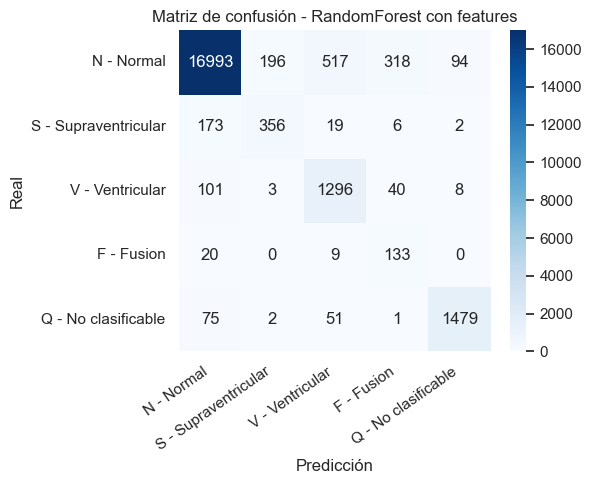

In [18]:
rf_clf = RandomForestClassifier(
    n_estimators=120,
    max_depth=12,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=-1
)

start = time.time()
rf_clf.fit(X_train_feat, y_train)
print(f"Tiempo de entrenamiento: {time.time() - start:.1f} segundos")

y_pred_rf = rf_clf.predict(X_test_feat)
evaluate_predictions("RandomForest features manuales", y_test, y_pred_rf)
plot_confusion(y_test, y_pred_rf, "Matriz de confusión - RandomForest con features")

,feature,importance
11,diff_std,0.141151
12,diff_max,0.125824
4,median,0.098680
13,diff_min,0.083152
8,area,0.075433
9,peak_idx_norm,0.066907
0,mean,0.062612
1,std,0.059825
15,n_values_over_075,0.059068
14,n_values_over_05,0.058830


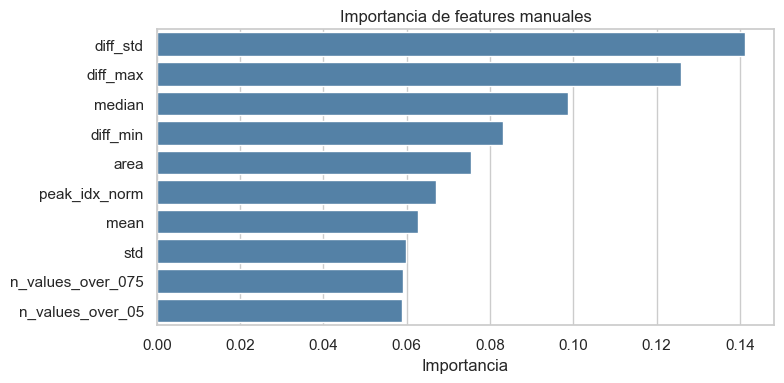

In [19]:
feature_importance = pd.DataFrame({
    "feature": X_train_feat.columns,
    "importance": rf_clf.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance.head(10))

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_importance.head(10), x="importance", y="feature", color="steelblue")
plt.title("Importancia de features manuales")
plt.xlabel("Importancia")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Preparación para modelos PyTorch

A partir de aquí se preparan los objetos comunes para las redes neuronales: `Dataset`, `DataLoader`, arquitectura base y función de entrenamiento/evaluación. Esta parte se reutiliza tanto para el MLP como para la CNN 1D.

In [20]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 256

train_ds = ECGDataset(X_train, y_train)
val_ds = ECGDataset(X_val, y_val)
test_ds = ECGDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_dl))
print("Batch X:", xb.shape)
print("Batch y:", yb.shape)

Batch X: torch.Size([256, 1, 187])
Batch y: torch.Size([256])


In [21]:
class ECGCNN(nn.Module):
    def __init__(self, n_classes=5, base_filters=32, dropout=0.10):
        super().__init__()
        c1 = base_filters
        c2 = base_filters * 2
        c3 = base_filters * 4

        self.features = nn.Sequential(
            nn.Conv1d(1, c1, kernel_size=7, padding=3),
            nn.BatchNorm1d(c1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout / 2),

            nn.Conv1d(c1, c2, kernel_size=5, padding=2),
            nn.BatchNorm1d(c2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),

            nn.Conv1d(c2, c3, kernel_size=5, padding=2),
            nn.BatchNorm1d(c3),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),

            nn.Conv1d(c3, c3, kernel_size=3, padding=1),
            nn.BatchNorm1d(c3),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c3, 64),
            nn.ReLU(),
            nn.Dropout(dropout + 0.05),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [22]:
# Revisamos de nuevo el desbalanceo antes de entrenar la red.
class_counts = np.bincount(y_train, minlength=len(class_names))
base_class_weights = class_counts.sum() / (len(class_names) * class_counts)

print("Conteo train:", class_counts)
print("Pesos balanceados base:", base_class_weights.round(3))

Conteo train: [61600  1889  4920   545  5466]
Pesos balanceados base: [ 0.242  7.879  3.025 27.31   2.723]


In [23]:
def run_epoch(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    y_true = []
    y_pred = []

    for xb, yb in dataloader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        y_true.extend(yb.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    total_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return total_loss, acc, f1, np.array(y_true), np.array(y_pred)

## Experimento 4: MLP sencillo

Antes de pasar a la CNN, se prueba un MLP. Este modelo ya es una red neuronal, pero trata los 187 puntos como un vector de entrada, sin explotar explícitamente la estructura local de la serie temporal. La comparación MLP vs CNN ayuda a justificar por qué usar convoluciones 1D tiene sentido en señales ECG.

In [24]:
class ECGMLP(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(N_TIMESTEPS, 128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)


def train_mlp(n_epochs=5):
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model_mlp = ECGMLP(n_classes=len(class_names)).to(DEVICE)
    criterion_mlp = nn.CrossEntropyLoss()
    optimizer_mlp = torch.optim.Adam(model_mlp.parameters(), lr=1e-3)

    history_mlp = []
    best_val_f1 = -1
    best_state_mlp = None

    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc, train_f1, _, _ = run_epoch(model_mlp, train_dl, criterion_mlp, optimizer_mlp)
        val_loss, val_acc, val_f1, _, _ = run_epoch(model_mlp, val_dl, criterion_mlp)

        history_mlp.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "train_f1_macro": train_f1,
            "val_f1_macro": val_f1
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state_mlp = {k: v.detach().cpu().clone() for k, v in model_mlp.state_dict().items()}

        print(
            f"Epoch {epoch:02d} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}"
        )

    model_mlp.load_state_dict({k: v.to(DEVICE) for k, v in best_state_mlp.items()})
    return model_mlp, pd.DataFrame(history_mlp)

model_mlp, history_mlp_df = train_mlp(n_epochs=5)
display(history_mlp_df)

Epoch 01 | train loss 0.5057 acc 0.8669 f1 0.3709 | val loss 0.2944 acc 0.9176 f1 0.4888


Epoch 02 | train loss 0.2765 acc 0.9243 f1 0.5360 | val loss 0.2102 acc 0.9409 f1 0.6167


Epoch 03 | train loss 0.2176 acc 0.9400 f1 0.6736 | val loss 0.1708 acc 0.9521 f1 0.7149


Epoch 04 | train loss 0.1877 acc 0.9481 f1 0.7290 | val loss 0.1573 acc 0.9571 f1 0.7867


Epoch 05 | train loss 0.1697 acc 0.9531 f1 0.7645 | val loss 0.1355 acc 0.9634 f1 0.8164


,epoch,train_loss,val_loss,train_acc,val_acc,train_f1_macro,val_f1_macro
0,1,0.505744,0.294392,0.866850,0.917618,0.370895,0.488807
1,2,0.276520,0.210176,0.924268,0.940917,0.535991,0.616745
2,3,0.217609,0.170818,0.940030,0.952109,0.673556,0.714939
3,4,0.187710,0.157267,0.948065,0.957058,0.729031,0.786705
4,5,0.169717,0.135505,0.953050,0.963377,0.764479,0.816390


Test loss MLP: 0.1452
MLP PyTorch
Accuracy   : 0.9607
F1 macro   : 0.7911
F1 weighted: 0.9575

                      precision    recall  f1-score   support

          N - Normal       0.96      1.00      0.98     18118
S - Supraventricular       0.95      0.51      0.67       556
     V - Ventricular       0.92      0.84      0.88      1448
          F - Fusion       0.78      0.36      0.50       162
 Q - No clasificable       0.98      0.89      0.94      1608

            accuracy                           0.96     21892
           macro avg       0.92      0.72      0.79     21892
        weighted avg       0.96      0.96      0.96     21892



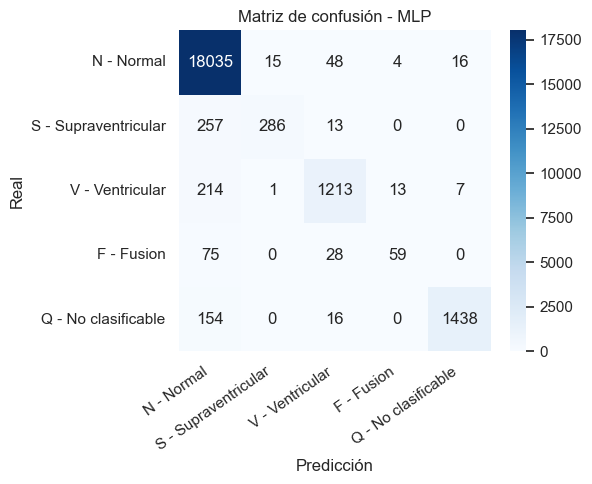

In [25]:
test_loss_mlp, test_acc_mlp, test_f1_mlp, y_true_mlp, y_pred_mlp = run_epoch(
    model_mlp,
    test_dl,
    nn.CrossEntropyLoss()
)

print(f"Test loss MLP: {test_loss_mlp:.4f}")
evaluate_predictions("MLP PyTorch", y_true_mlp, y_pred_mlp)
plot_confusion(y_true_mlp, y_pred_mlp, "Matriz de confusión - MLP")

## Experimento 5: BiLSTM

También se pruebo una arquitectura recurrente. En este caso se usa una **BiLSTM** pequeña, que lee la señal en ambos sentidos.

La expectativa no es necesariamente que supere a la CNN. En latidos ECG ya segmentados, la clase suele depender mucho de formas locales concretas, por lo que una CNN 1D suele ser más eficiente. Aun así, incluir una BiLSTM hace la comparación más completa y permite comprobar empíricamente si una arquitectura recurrente aporta algo en esta tarea.

In [26]:
class ECGBiLSTM(nn.Module):
    def __init__(self, n_classes=5, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        # x llega como (batch, canales=1, timesteps). LSTM espera (batch, timesteps, features).
        x = x.squeeze(1).unsqueeze(-1)
        _, (h_n, _) = self.lstm(x)
        h_forward = h_n[-2]
        h_backward = h_n[-1]
        h = torch.cat([h_forward, h_backward], dim=1)
        return self.classifier(h)


def train_bilstm(n_epochs=4):
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model_lstm = ECGBiLSTM(n_classes=len(class_names), hidden_size=32).to(DEVICE)
    criterion_lstm = nn.CrossEntropyLoss()
    optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

    history_lstm = []
    best_val_f1 = -1
    best_state_lstm = None

    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc, train_f1, _, _ = run_epoch(model_lstm, train_dl, criterion_lstm, optimizer_lstm)
        val_loss, val_acc, val_f1, _, _ = run_epoch(model_lstm, val_dl, criterion_lstm)

        history_lstm.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "train_f1_macro": train_f1,
            "val_f1_macro": val_f1
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state_lstm = {k: v.detach().cpu().clone() for k, v in model_lstm.state_dict().items()}

        print(
            f"Epoch {epoch:02d} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}"
        )

    model_lstm.load_state_dict({k: v.to(DEVICE) for k, v in best_state_lstm.items()})
    return model_lstm, pd.DataFrame(history_lstm)

model_lstm, history_lstm_df = train_bilstm(n_epochs=4)
display(history_lstm_df)

Epoch 01 | train loss 0.7412 acc 0.8230 f1 0.1824 | val loss 0.6190 acc 0.8277 f1 0.1811


Epoch 02 | train loss 0.5182 acc 0.8594 f1 0.3001 | val loss 0.3807 acc 0.8972 f1 0.3872


Epoch 03 | train loss 0.3541 acc 0.9121 f1 0.4750 | val loss 0.3041 acc 0.9293 f1 0.5404


Epoch 04 | train loss 0.2944 acc 0.9285 f1 0.5410 | val loss 0.2465 acc 0.9372 f1 0.5684


,epoch,train_loss,val_loss,train_acc,val_acc,train_f1_macro,val_f1_macro
0,1,0.741237,0.618980,0.822951,0.827699,0.182387,0.181146
1,2,0.518186,0.380668,0.859366,0.897213,0.300082,0.387241
2,3,0.354095,0.304144,0.912147,0.929268,0.475000,0.540422
3,4,0.294368,0.246488,0.928527,0.937186,0.541038,0.568438


Test loss BiLSTM: 0.2529
BiLSTM PyTorch
Accuracy   : 0.9345
F1 macro   : 0.5590
F1 weighted: 0.9201

                      precision    recall  f1-score   support

          N - Normal       0.94      1.00      0.96     18118
S - Supraventricular       0.82      0.08      0.15       556
     V - Ventricular       0.86      0.69      0.76      1448
          F - Fusion       0.00      0.00      0.00       162
 Q - No clasificable       0.97      0.86      0.91      1608

            accuracy                           0.93     21892
           macro avg       0.72      0.53      0.56     21892
        weighted avg       0.92      0.93      0.92     21892



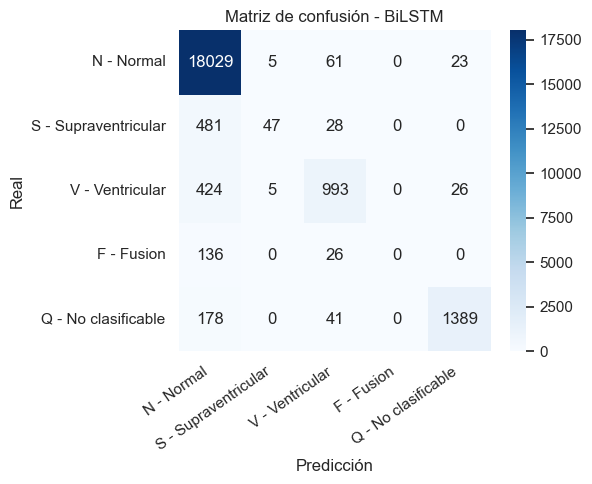

In [27]:
test_loss_lstm, test_acc_lstm, test_f1_lstm, y_true_lstm, y_pred_lstm = run_epoch(
    model_lstm,
    test_dl,
    nn.CrossEntropyLoss()
)

print(f"Test loss BiLSTM: {test_loss_lstm:.4f}")
evaluate_predictions("BiLSTM PyTorch", y_true_lstm, y_pred_lstm)
plot_confusion(y_true_lstm, y_pred_lstm, "Matriz de confusión - BiLSTM")

## Modelo Deep Learning: CNN 1D y búsqueda de hiperparámetros

Después de los baselines del MLP y la LSTM, el modelo principal es una red convolucional 1D. La idea es que las convoluciones aprendan patrones locales de la morfología del latido. El modelo es sencillo a propósito, porque el objetivo no es crear una arquitectura enorme, sino tener una solución razonable, reproducible y comparable con los baselines y arquitecturas sencillas.

Como mejora respecto a entrenar una única red, pruebo una búsqueda pequeña de hiperparámetros. No es una búsqueda exhaustiva, pero sí permite justificar mejor la configuración final. Comparo cambios en:

- número base de filtros convolucionales,
- dropout,
- learning rate,
- uso o no de pesos de clase suavizados.

La selección se hace con **F1 macro en validación**, porque el dataset está desbalanceado y no queremos escoger un modelo que solo funcione bien en la clase normal.

### Búsqueda de hiperparámetros

Entrenamos varias configuraciones durante pocas épocas y nos quedamos con la que obtiene mejor F1 macro en validación. Es una búsqueda acotada para que el notebook ejecute en un tiempo razonable.

In [28]:
def get_class_weights(mode):
    if mode == "none":
        return None
    if mode == "balanced":
        weights = base_class_weights
    elif mode == "sqrt":
        weights = np.sqrt(base_class_weights)
    elif mode == "soft":
        weights = base_class_weights ** 0.35
    else:
        raise ValueError(f"Modo de pesos no reconocido: {mode}")
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def train_cnn_config(config, n_epochs=4, verbose=True):
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model = ECGCNN(
        n_classes=len(class_names),
        base_filters=config["base_filters"],
        dropout=config["dropout"]
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=get_class_weights(config["class_weights"]))
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    history = []
    best_val_f1 = -1
    best_state = None

    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc, train_f1, _, _ = run_epoch(model, train_dl, criterion, optimizer)
        val_loss, val_acc, val_f1, _, _ = run_epoch(model, val_dl, criterion)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "train_f1_macro": train_f1,
            "val_f1_macro": val_f1
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose:
            print(
                f"Epoch {epoch:02d} | "
                f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
                f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}"
            )

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    return model, pd.DataFrame(history), best_state

In [29]:
search_configs = [
    {"nombre": "CNN base", "base_filters": 32, "dropout": 0.10, "lr": 1e-3, "class_weights": "none"},
    {"nombre": "CNN pequeña", "base_filters": 16, "dropout": 0.10, "lr": 1e-3, "class_weights": "none"},
    {"nombre": "CNN dropout alto", "base_filters": 32, "dropout": 0.20, "lr": 1e-3, "class_weights": "none"},
    {"nombre": "CNN pesos suaves", "base_filters": 32, "dropout": 0.10, "lr": 1e-3, "class_weights": "soft"},
    {"nombre": "CNN lr bajo", "base_filters": 32, "dropout": 0.10, "lr": 5e-4, "class_weights": "none"},
]

SEARCH_EPOCHS = 4
search_rows = []

for config in search_configs:
    print(f"Probando: {config['nombre']}")
    _, cfg_history, _ = train_cnn_config(config, n_epochs=SEARCH_EPOCHS, verbose=False)
    best_idx = cfg_history["val_f1_macro"].idxmax()
    best_row = cfg_history.loc[best_idx]

    search_rows.append({
        "config": config["nombre"],
        "base_filters": config["base_filters"],
        "dropout": config["dropout"],
        "lr": config["lr"],
        "class_weights": config["class_weights"],
        "best_epoch": int(best_row["epoch"]),
        "val_accuracy": best_row["val_acc"],
        "val_f1_macro": best_row["val_f1_macro"]
    })

search_results_df = pd.DataFrame(search_rows).sort_values("val_f1_macro", ascending=False).reset_index(drop=True)
display(search_results_df.round(4))

selected_name = search_results_df.loc[0, "config"]
selected_config = next(config for config in search_configs if config["nombre"] == selected_name)
print("Configuración seleccionada:", selected_config)

Probando: CNN base


Probando: CNN pequeña


Probando: CNN dropout alto


Probando: CNN pesos suaves


Probando: CNN lr bajo


,config,base_filters,dropout,lr,class_weights,best_epoch,val_accuracy,val_f1_macro
0,CNN base,32,0.1,0.0010,none,4,0.9765,0.8703
1,CNN pesos suaves,32,0.1,0.0010,soft,3,0.9705,0.8570
2,CNN dropout alto,32,0.2,0.0010,none,4,0.9686,0.8432
3,CNN lr bajo,32,0.1,0.0005,none,4,0.9731,0.8388
4,CNN pequeña,16,0.1,0.0010,none,4,0.9642,0.7985


Configuración seleccionada: {'nombre': 'CNN base', 'base_filters': 32, 'dropout': 0.1, 'lr': 0.001, 'class_weights': 'none'}


### Interpretación de la búsqueda

La configuración seleccionada es la que obtiene mejor F1 macro en validación. Esto es importante por dos motivos:

1. El dataset está muy desbalanceado, así que no conviene elegir solo por accuracy.
2. La opción con pesos de clase suavizados se ha probado explícitamente, pero en esta ejecución no supera a la CNN base. Por tanto, no se descarta el desbalanceo: se evalúa y se toma la decisión usando validación.

No se aplica upsampling/downsampling porque el desbalanceo es grande y modificar artificialmente el conjunto podría introducir sobreajuste en clases con muy pocos ejemplos. Prefiero mantener los datos originales, comparar con F1 macro y probar una reponderación suave como parte de la búsqueda.

Sobre ROCKET/MiniROCKET: son métodos muy fuertes para clasificación de series temporales. En este proyecto los dejo como posible baseline avanzado porque el enunciado pide aplicar un algoritmo de Deep Learning adecuado, y la CNN 1D es el modelo principal de la entrega. MiniROCKET sería una buena ampliación si se quisiera una comparación extra contra un método cercano al estado del arte, pero no es imprescindible.

### Entrenamiento final de la CNN seleccionada

Una vez escogida la configuración con validación, entrenamos de nuevo durante algunas épocas más y se conserva el mejor estado según F1 macro de validación.

In [30]:
N_EPOCHS = 6
model, history_df, best_state = train_cnn_config(selected_config, n_epochs=N_EPOCHS, verbose=True)
display(history_df)

Epoch 01 | train loss 0.3065 acc 0.9160 f1 0.5166 | val loss 0.1585 acc 0.9565 f1 0.6561


Epoch 02 | train loss 0.1514 acc 0.9590 f1 0.6756 | val loss 0.1270 acc 0.9666 f1 0.7079


Epoch 03 | train loss 0.1266 acc 0.9645 f1 0.7320 | val loss 0.1105 acc 0.9695 f1 0.8245


Epoch 04 | train loss 0.1076 acc 0.9703 f1 0.8235 | val loss 0.0856 acc 0.9765 f1 0.8703


Epoch 05 | train loss 0.0988 acc 0.9727 f1 0.8489 | val loss 0.0790 acc 0.9788 f1 0.8873


Epoch 06 | train loss 0.0910 acc 0.9748 f1 0.8609 | val loss 0.0705 acc 0.9798 f1 0.8932


,epoch,train_loss,val_loss,train_acc,val_acc,train_f1_macro,val_f1_macro
0,1,0.306465,0.158515,0.915950,0.956525,0.516649,0.656075
1,2,0.151445,0.127017,0.959030,0.966575,0.675572,0.707909
2,3,0.126621,0.110547,0.964458,0.969545,0.732048,0.824498
3,4,0.107585,0.085616,0.970304,0.976549,0.823520,0.870298
4,5,0.098837,0.078989,0.972655,0.978757,0.848862,0.887335
5,6,0.091021,0.070539,0.974778,0.979823,0.860882,0.893213


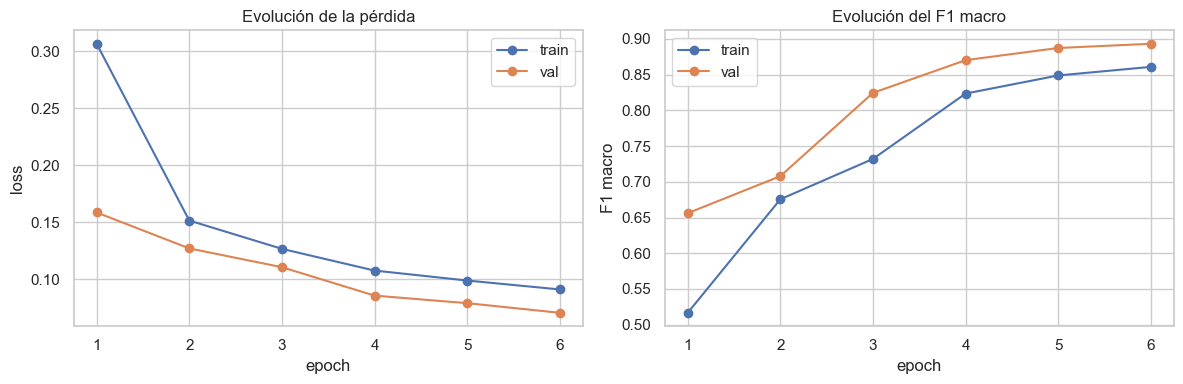

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val")
axes[0].set_title("Evolución de la pérdida")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_f1_macro"], marker="o", label="train")
axes[1].plot(history_df["epoch"], history_df["val_f1_macro"], marker="o", label="val")
axes[1].set_title("Evolución del F1 macro")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("F1 macro")
axes[1].legend()

plt.tight_layout()
plt.show()

Test loss CNN: 0.0785
CNN 1D PyTorch (CNN base)
Accuracy   : 0.9784
F1 macro   : 0.8766
F1 weighted: 0.9772

                      precision    recall  f1-score   support

          N - Normal       0.98      0.99      0.99     18118
S - Supraventricular       0.93      0.60      0.73       556
     V - Ventricular       0.94      0.94      0.94      1448
          F - Fusion       0.76      0.71      0.73       162
 Q - No clasificable       0.99      0.98      0.99      1608

            accuracy                           0.98     21892
           macro avg       0.92      0.85      0.88     21892
        weighted avg       0.98      0.98      0.98     21892



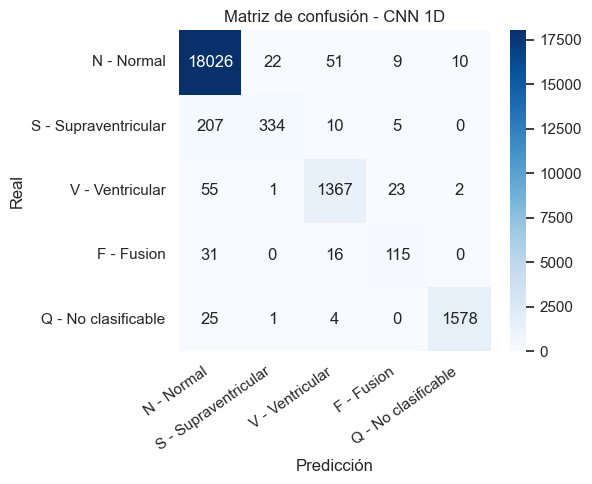

In [32]:
# Evaluamos en test solo después de haber elegido la configuración con validación.
model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

test_loss, test_acc, test_f1, y_true_cnn, y_pred_cnn = run_epoch(model, test_dl, nn.CrossEntropyLoss())
print(f"Test loss CNN: {test_loss:.4f}")
evaluate_predictions(f"CNN 1D PyTorch ({selected_config['nombre']})", y_true_cnn, y_pred_cnn)
plot_confusion(y_true_cnn, y_pred_cnn, "Matriz de confusión - CNN 1D")

## Comparación final de modelos

La comparación se hace principalmente con F1 macro por lo que hemos estado comentando del desbalanveo. Aun así, también se muestra accuracy y F1 weighted para tener una visión más completa.

In [33]:
results_df = pd.DataFrame(results).drop_duplicates(subset="Modelo", keep="last")
results_df = results_df.sort_values("F1 macro", ascending=False).reset_index(drop=True)
display(results_df.round(4))

,Modelo,Accuracy,F1 macro,F1 weighted
0,CNN 1D PyTorch (CNN base),0.9784,0.8766,0.9772
1,MLP PyTorch,0.9607,0.7911,0.9575
2,RandomForest features manuales,0.9253,0.7407,0.9314
3,BiLSTM PyTorch,0.9345,0.5590,0.9201
4,RidgeClassifier balanceado,0.6204,0.4488,0.6970
5,Baseline clase mayoritaria,0.8276,0.1811,0.7495


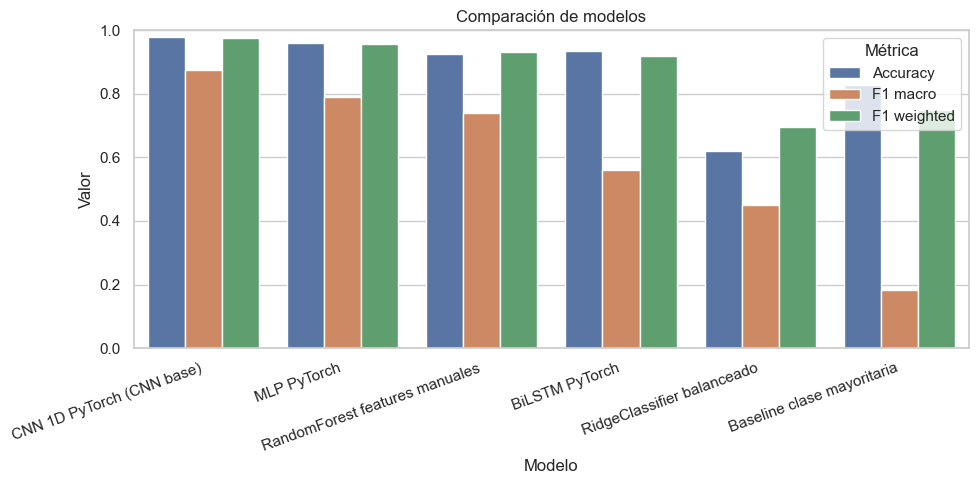

In [34]:
plot_df = results_df.melt(id_vars="Modelo", value_vars=["Accuracy", "F1 macro", "F1 weighted"], var_name="Métrica", value_name="Valor")

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Modelo", y="Valor", hue="Métrica")
plt.ylim(0, 1)
plt.title("Comparación de modelos")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [35]:
# Analizamos los errores de la CNN por pares real/predicho
errors = pd.DataFrame({"real": y_true_cnn, "pred": y_pred_cnn})
errors = errors[errors["real"] != errors["pred"]]

error_pairs = (
    errors.value_counts(["real", "pred"])
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)
error_pairs["real_nombre"] = error_pairs["real"].map(class_names)
error_pairs["pred_nombre"] = error_pairs["pred"].map(class_names)

display(error_pairs.head(10))

,real,pred,n,real_nombre,pred_nombre
0,1,0,207,S - Supraventricular,N - Normal
1,2,0,55,V - Ventricular,N - Normal
2,0,2,51,N - Normal,V - Ventricular
3,3,0,31,F - Fusion,N - Normal
4,4,0,25,Q - No clasificable,N - Normal
5,2,3,23,V - Ventricular,F - Fusion
6,0,1,22,N - Normal,S - Supraventricular
7,3,2,16,F - Fusion,V - Ventricular
8,0,4,10,N - Normal,Q - No clasificable
9,1,2,10,S - Supraventricular,V - Ventricular


## Conclusiones

En esta práctica se ha abordado un problema de clasificación supervisada de series temporales usando señales ECG. El análisis inicial muestra que el dataset está muy desbalanceado, por el peso de la clase normal. Por eso se ha decidido comparar los modelos F1 macro.

El baseline de clase mayoritaria obtiene una accuracy aparentemente alta, pero falla completamente en las clases minoritarias. El clasificador lineal balanceado mejora la cobertura de clases pequeñas, aunque baja bastante la accuracy global. El experimento con features manuales aporta una referencia más interpretable, el MLP permite comprobar qué ocurre al usar una red neuronal actua explícitamente sobre patrones locales, y la BiLSTM añade una comparación recurrente.

En esta tarea concreta, la BiLSTM no supera al MLP ni a la CNN. Tiene una accuracy razonable, pero su F1 macro es peor porque no detecta bien algunas clases minoritarias. Esto tiene sentido: los latidos ya están segmentados y la información más relevante está en la morfología local de la señal, donde una CNN 1D suele ser más eficaz y eficiente.

Finalmente, la CNN 1D aprovecha mejor la forma temporal de la señal y consigue el mejor equilibrio en la comparación final. La búsqueda de hiperparámetros se ha usado para justificar la configuración de la red con datos de validación, evitando escogerla directamente por el resultado en test.

Como posible mejora posterior, se podrían probar arquitecturas más avanzadas vistas en clase, como InceptionTime o ROCKET/MiniROCKET, o entrenar durante más épocas con early stopping. Aun así, la solución actual cubre un flujo completo de proyecto de series temporales.

In [36]:
best_row = results_df.iloc[0]
print("Modelo seleccionado:", best_row["Modelo"])
print(f"Accuracy: {best_row['Accuracy']:.4f}")
print(f"F1 macro: {best_row['F1 macro']:.4f}")
print(f"F1 weighted: {best_row['F1 weighted']:.4f}")

Modelo seleccionado: CNN 1D PyTorch (CNN base)
Accuracy: 0.9784
F1 macro: 0.8766
F1 weighted: 0.9772
